# Ансамблевые модели машинного обучения

Лабораторная работа №5.

**Задача:** бинарная классификация — предсказать, выжил ли пассажир «Титаника» (`survived`).

**Датасет:** `seaborn.load_dataset('titanic')` — числовые и категориальные признаки, есть пропуски.

## 1) Описание набора данных

- Документация Seaborn: https://seaborn.pydata.org/generated/seaborn.load_dataset.html
- Исходное описание: https://www.kaggle.com/c/titanic/data

Набор содержит **891** запись. Целевая переменная — `survived` (0 — погиб, 1 — выжил).

| Тип | Признаки |
|-----|----------|
| Числовые | `pclass`, `age`, `sibsp`, `parch`, `fare` |
| Категориальные | `sex`, `embarked` |

В данных есть **пропуски** (в `age` и `embarked`), что позволяет показать этап предобработки.
Датасет хорошо подходит для сравнения ансамблевых методов на задаче классификации.

## Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
)

%matplotlib inline
sns.set(style="ticks")

## Загрузка и первичный осмотр

In [2]:
df = sns.load_dataset('titanic')
print(f'Размер: {df.shape}')
df.head()

Размер: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
print('Пропуски по столбцам:')
print(df.isna().sum())
print()
print('Распределение целевой переменной:')
print(df['survived'].value_counts(normalize=True).round(3))

Пропуски по столбцам:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Распределение целевой переменной:
survived
0    0.616
1    0.384
Name: proportion, dtype: float64


## Предобработка данных

Выбираем признаки без утечки информации из целевой переменной (`alive`, `class`, `who`, `deck` и т.п. не используем).
Числовые пропуски заполняем медианой, категориальные — модой. Категориальные признаки кодируем one-hot.

In [4]:
FEATURES = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
TARGET = 'survived'

X = df[FEATURES].copy()
y = df[TARGET]

numeric_features = ['pclass', 'age', 'sibsp', 'parch', 'fare']
categorical_features = ['sex', 'embarked']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

## Разделение на обучающую и тестовую выборки

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

print(f'Обучающая выборка: {X_train.shape[0]} объектов')
print(f'Тестовая выборка:   {X_test.shape[0]} объектов')

Обучающая выборка: 668 объектов
Тестовая выборка:   223 объектов


## Обучение ансамблевых моделей

Обучаем пять моделей:
1. **Bagging** — бэггинг на деревьях решений;
2. **Random Forest** — случайный лес;
3. **Extra Trees** — сверхслучайные деревья;
4. **AdaBoost** — адаптивный бустинг;
5. **Gradient Boosting** — градиентный бустинг.

Первые три относятся к группе **бэггинга**, последние две — к **бустингу**.

In [6]:
RANDOM_STATE = 42

models = {
    'Bagging': Pipeline([
        ('prep', preprocessor),
        ('model', BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
            n_estimators=100,
            random_state=RANDOM_STATE,
        )),
    ]),
    'Random Forest': Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=100,
            max_depth=8,
            random_state=RANDOM_STATE,
        )),
    ]),
    'Extra Trees': Pipeline([
        ('prep', preprocessor),
        ('model', ExtraTreesClassifier(
            n_estimators=100,
            max_depth=8,
            random_state=RANDOM_STATE,
        )),
    ]),
    'AdaBoost': Pipeline([
        ('prep', preprocessor),
        ('model', AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
            n_estimators=100,
            learning_rate=0.1,
            random_state=RANDOM_STATE,
        )),
    ]),
    'Gradient Boosting': Pipeline([
        ('prep', preprocessor),
        ('model', GradientBoostingClassifier(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.1,
            random_state=RANDOM_STATE,
        )),
    ]),
}

In [7]:
results = []

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Модель': name,
        'Accuracy': acc,
        'F1-score': f1,
    })

    print(f'=== {name} ===')
    print(classification_report(y_test, y_pred, target_names=['погиб', 'выжил']))
    print()

=== Bagging ===
              precision    recall  f1-score   support

       погиб       0.78      0.94      0.85       137
       выжил       0.86      0.57      0.69        86

    accuracy                           0.80       223
   macro avg       0.82      0.76      0.77       223
weighted avg       0.81      0.80      0.79       223


=== Random Forest ===
              precision    recall  f1-score   support

       погиб       0.80      0.89      0.84       137
       выжил       0.79      0.65      0.71        86

    accuracy                           0.80       223
   macro avg       0.80      0.77      0.78       223
weighted avg       0.80      0.80      0.79       223


=== Extra Trees ===
              precision    recall  f1-score   support

       погиб       0.79      0.88      0.83       137
       выжил       0.77      0.63      0.69        86

    accuracy                           0.78       223
   macro avg       0.78      0.76      0.76       223
weighted avg  

=== AdaBoost ===
              precision    recall  f1-score   support

       погиб       0.80      0.93      0.86       137
       выжил       0.85      0.62      0.72        86

    accuracy                           0.81       223
   macro avg       0.82      0.78      0.79       223
weighted avg       0.82      0.81      0.80       223




=== Gradient Boosting ===
              precision    recall  f1-score   support

       погиб       0.79      0.91      0.85       137
       выжил       0.82      0.62      0.70        86

    accuracy                           0.80       223
   macro avg       0.80      0.76      0.77       223
weighted avg       0.80      0.80      0.79       223




## Сравнение качества моделей

Для задачи бинарной классификации используем метрики **Accuracy** (доля верных ответов) и **F1-score** (баланс precision и recall).

In [8]:
results_df = pd.DataFrame(results).sort_values('F1-score', ascending=False).reset_index(drop=True)
results_df

,Модель,Accuracy,F1-score
0,AdaBoost,0.811659,0.716216
1,Random Forest,0.798206,0.713376
2,Gradient Boosting,0.798206,0.701987
3,Extra Trees,0.784753,0.692308
4,Bagging,0.798206,0.685315


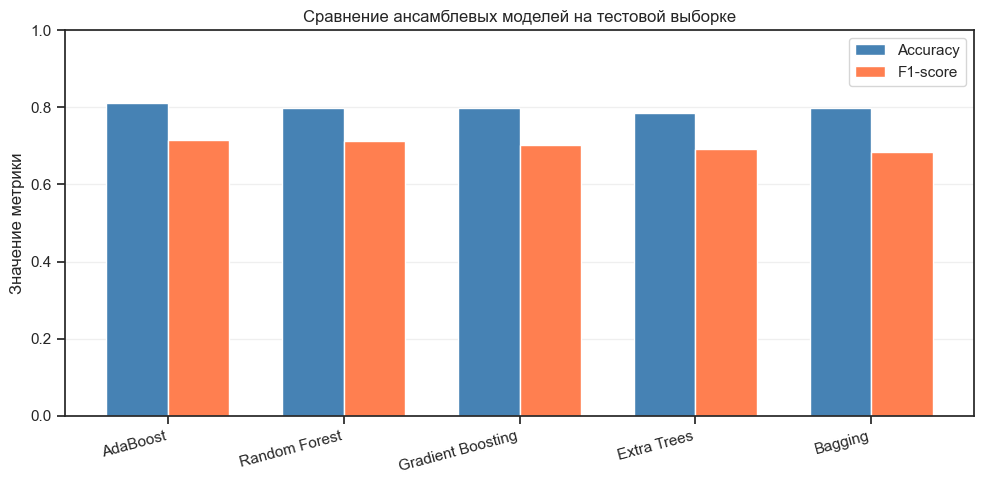

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(results_df))
width = 0.35

ax.bar(x - width / 2, results_df['Accuracy'], width, label='Accuracy', color='steelblue')
ax.bar(x + width / 2, results_df['F1-score'], width, label='F1-score', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Модель'], rotation=15, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение ансамблевых моделей на тестовой выборке')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Выводы

1. Все пять ансамблевых моделей обучены на одних и тех же данных после предобработки (заполнение пропусков, кодирование категорий, масштабирование числовых признаков).
2. Модели группы **бэггинга** (Bagging, Random Forest, Extra Trees) строят независимые базовые классификаторы и усредняют их предсказания — это снижает дисперсию.
3. **AdaBoost** и **Gradient Boosting** последовательно исправляют ошибки предыдущих слабых классификаторов, что часто даёт высокое качество на табличных данных.
4. По метрикам на тестовой выборке лучшую модель можно выбрать из таблицы и графика выше; как правило, случайный лес и градиентный бустинг показывают сопоставимое или лучшее качество на этом датасете.